<a href="https://colab.research.google.com/github/scudilio/Churn_model/blob/master/RN_AULA_10_CNN_IMAGENS_COLORIDAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN para Imagens de Gatos e cachorros

In [ ]:
!pip install tensorflow

In [ ]:
import numpy as np
import tensorflow as tf

In [ ]:
np.__version__, tf.__version__

('2.0.2', '2.19.0')

In [ ]:
import tempfile
import zipfile

temp_dir = tempfile.TemporaryDirectory() #diretorio temporario para receber as imagens

print(temp_dir)

<TemporaryDirectory '/tmp/tmp_eq5urtr'>


In [ ]:
# r read, leitura do arquivo
with zipfile.ZipFile('dataset.zip', 'r') as zip:
  zip.extractall(temp_dir.name)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing import image #leitura das imagens
from tensorflow.keras.preprocessing.image import ImageDataGenerator #leitura de imagens de um diretorio

In [ ]:
classificador = Sequential()
classificador.add(InputLayer(shape = (64, 64, 3)))

classificador.add(Conv2D(32, (3, 3), activation = 'relu')) #extraindo caracteristica
classificador.add(BatchNormalization())
classificador.add(MaxPooling2D(pool_size=(2, 2))) #redução de dimensão + extraçao da maxima caracterisitca

classificador.add(Conv2D(32, (3, 3), activation = 'relu'))
classificador.add(BatchNormalization())
classificador.add(MaxPooling2D(pool_size=(2, 2)))

classificador.add(Flatten())

classificador.add(Dense(units = 128, activation='relu'))
classificador.add(Dropout(0.2))
classificador.add(Dense(units = 64, activation='relu'))
classificador.add(Dropout(0.2))

classificador.add(Dense(units = 1, activation='sigmoid')) #ultima camanda

In [ ]:
classificador.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 821,665 (3.13 MB)

 Trainable params: 821,537 (3.13 MB)

 Non-trainable params: 128 (512.00 B)

In [ ]:
classificador.compile(optimizer='adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [ ]:
#utilizar as imagens para gerar novas imagens
gerador_treinamento = ImageDataGenerator(rescale=1./255,
                                         rotation_range=7,
                                         horizontal_flip = True,
                                         shear_range=0.2,
                                         height_shift_range = 0.07,
                                         zoom_range=0.2)

In [ ]:
# normalizando as imagens
gerador_teste = ImageDataGenerator(rescale=1./255)

In [ ]:
base_treinamento = gerador_treinamento.flow_from_directory(f'{temp_dir.name}/dataset/training_set',
                                                           target_size = (64, 64),
                                                           batch_size = 32,
                                                           class_mode='binary')

Found 4000 images belonging to 2 classes.


In [ ]:
base_teste = gerador_teste.flow_from_directory(f'{temp_dir.name}/dataset/test_set',
                                               target_size = (64, 64),
                                               batch_size = 32,
                                               class_mode='binary')

Found 1000 images belonging to 2 classes.


In [ ]:
# aumentar o numero de epocas para melhorar a rede
classificador.fit(base_treinamento, epochs = 10, validation_data = base_teste)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 298ms/step - accuracy: 0.5590 - loss: 0.7841 - val_accuracy: 0.5070 - val_loss: 0.8338
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 35s 281ms/step - accuracy: 0.6075 - loss: 0.6835 - val_accuracy: 0.5010 - val_loss: 1.9299
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 34s 272ms/step - accuracy: 0.6528 - loss: 0.6398 - val_accuracy: 0.5520 - val_loss: 0.7393
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 35s 280ms/step - accuracy: 0.6618 - loss: 0.6342 - val_accuracy: 0.6770 - val_loss: 0.6017
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 38s 301ms/step - accuracy: 0.6852 - loss: 0.5906 - val_accuracy: 0.6910 - val_loss: 0.5832
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 42s 304ms/step - accuracy: 0.7055 - loss: 0.5712 - val_accuracy: 0.6970 - val_loss: 0.5791
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 34s 275ms/step - accuracy: 0.7122 - loss: 0.5602 - val_accuracy: 0.6520 - val_loss: 0.6313
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 35s 283ms/step - accuracy: 0.7247 - loss: 0

##Melhorando a CNN com early stopping

In [ ]:
# ─────────────────────────────────────────────────────────────────
# 1. IMPORTS
# ─────────────────────────────────────────────────────────────────
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (InputLayer, Conv2D, BatchNormalization,
                                     MaxPooling2D, Flatten, Dense, Dropout)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

In [ ]:

# ─────────────────────────────────────────────────────────────────
# 2. GERADORES DE IMAGEM
# ─────────────────────────────────────────────────────────────────

# Treinamento — com data augmentation
gerador_treinamento = ImageDataGenerator(
    rescale=1./255,
    rotation_range=7,
    horizontal_flip=True,
    shear_range=0.2,
    height_shift_range=0.07,
    zoom_range=0.2
)


In [ ]:


# Teste/validação — SÓ rescale, sem augmentation
# (augmentation em validação contamina a métrica de avaliação)
gerador_teste = ImageDataGenerator(rescale=1./255)

base_treinamento = gerador_treinamento.flow_from_directory(
    f'{temp_dir.name}/dataset/training_set',
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary'
)

base_teste = gerador_teste.flow_from_directory(
    f'{temp_dir.name}/dataset/test_set',
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary',
    shuffle=False  # importante: não embaralhar validação
)


Found 4000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [ ]:

# ─────────────────────────────────────────────────────────────────
# 3. ARQUITETURA DO MODELO (sem alteração)
# ─────────────────────────────────────────────────────────────────
classificador = Sequential()
classificador.add(InputLayer(shape=(64, 64, 3)))

classificador.add(Conv2D(32, (3, 3), activation='relu'))
classificador.add(BatchNormalization())
classificador.add(MaxPooling2D(pool_size=(2, 2)))

classificador.add(Conv2D(32, (3, 3), activation='relu'))
classificador.add(BatchNormalization())
classificador.add(MaxPooling2D(pool_size=(2, 2)))

classificador.add(Flatten())

classificador.add(Dense(units=128, activation='relu'))
classificador.add(Dropout(0.2))
classificador.add(Dense(units=64, activation='relu'))
classificador.add(Dropout(0.2))

classificador.add(Dense(units=1, activation='sigmoid'))

classificador.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

classificador.summary()




Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 29, 29, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 821,665 (3.13 MB)

 Trainable params: 821,537 (3.13 MB)

 Non-trainable params: 128 (512.00 B)

In [ ]:
# ─────────────────────────────────────────────────────────────────
# 4. CALLBACKS — Early Stopping + salvar melhor modelo
# ─────────────────────────────────────────────────────────────────

early_stopping = EarlyStopping(
    monitor='val_accuracy',   # maximizar acurácia na validação
    patience=10,              # aguarda 10 épocas sem melhora antes de parar
    mode='max',
    restore_best_weights=True,# restaura os pesos da MELHOR época automaticamente
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath='melhor_modelo.keras',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,      # só salva quando val_accuracy melhora
    verbose=1
)


Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.5798 - loss: 0.7691
Epoch 1: val_accuracy improved from None to 0.50000, saving model to melhor_modelo.keras

Epoch 1: finished saving model to melhor_modelo.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 36s 291ms/step - accuracy: 0.5925 - loss: 0.7308 - val_accuracy: 0.5000 - val_loss: 1.5438
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.6324 - loss: 0.6613
Epoch 2: val_accuracy did not improve from 0.50000
125/125 ━━━━━━━━━━━━━━━━━━━━ 35s 280ms/step - accuracy: 0.6313 - loss: 0.6564 - val_accuracy: 0.4960 - val_loss: 1.7591
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.6629 - loss: 0.6153
Epoch 3: val_accuracy improved from 0.50000 to 0.52600, saving model to melhor_modelo.keras

Epoch 3: finished saving model to melhor_modelo.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 36s 290ms/step - accuracy: 0.6622 - loss: 0.6166 - val_accuracy: 0.5260 - val_loss: 1.0523
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━

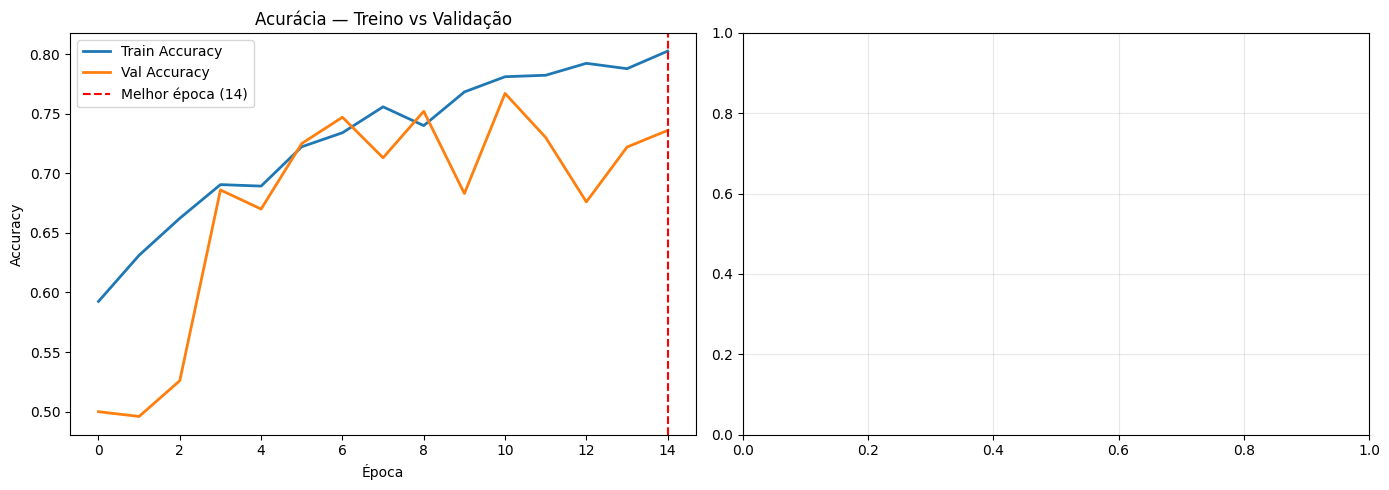

In [ ]:
# ─────────────────────────────────────────────────────────────────
# 5. TREINAMENTO
# epochs alto — early stopping para no momento certo
# ─────────────────────────────────────────────────────────────────
historico = classificador.fit(
    base_treinamento,
    epochs=15,
    validation_data=base_teste,
    callbacks=[early_stopping, checkpoint]
)

# ─────────────────────────────────────────────────────────────────
# 6. DIAGNÓSTICO — onde parou e qual foi o pico
# ─────────────────────────────────────────────────────────────────

# stopped_epoch == 0 significa que rodou todas as épocas sem parar
parou_na_epoca = early_stopping.stopped_epoch
if parou_na_epoca == 0:
    melhor_epoca = len(historico.history['val_accuracy']) - 1
    print("⚠️  Early Stopping não foi acionado — considere aumentar epochs.")
else:
    melhor_epoca = parou_na_epoca - early_stopping.patience
    print(f"✅ Treino parou na época : {parou_na_epoca}")
    print(f"✅ Melhor época          : {melhor_epoca}")

melhor_val_acc = max(historico.history['val_accuracy'])
print(f"✅ Melhor val_accuracy   : {melhor_val_acc:.4f}")

# ─────────────────────────────────────────────────────────────────
# 7. VISUALIZAÇÃO — curvas de aprendizado
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# — Acurácia
axes[0].plot(historico.history['accuracy'],     label='Train Accuracy', linewidth=2)
axes[0].plot(historico.history['val_accuracy'], label='Val Accuracy',   linewidth=2)
axes[0].axvline(melhor_epoca, color='red', linestyle='--',
                label=f'Melhor época ({melhor_epoca})', linewidth=1.5)
axes[0].set_title('Acurácia — Treino vs Validação')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

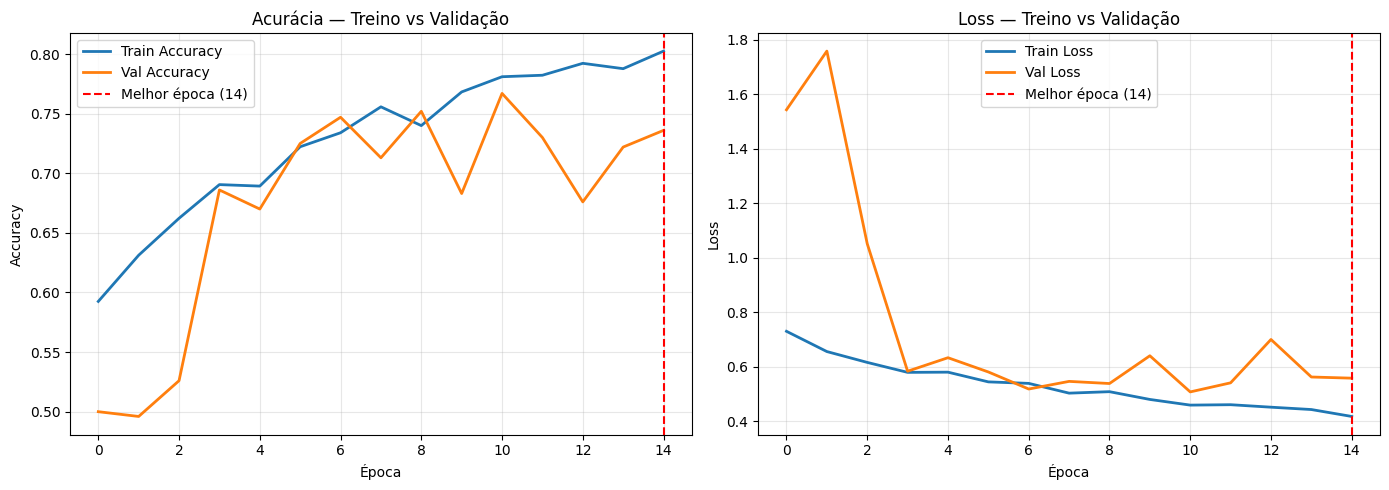

In [ ]:
# ─────────────────────────────────────────────────────────────────
# 7. VISUALIZAÇÃO — curvas de aprendizado
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# — Acurácia
axes[0].plot(historico.history['accuracy'],     label='Train Accuracy', linewidth=2)
axes[0].plot(historico.history['val_accuracy'], label='Val Accuracy',   linewidth=2)
axes[0].axvline(melhor_epoca, color='red', linestyle='--',
                label=f'Melhor época ({melhor_epoca})', linewidth=1.5)
axes[0].set_title('Acurácia — Treino vs Validação')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# — Loss
axes[1].plot(historico.history['loss'],     label='Train Loss', linewidth=2)
axes[1].plot(historico.history['val_loss'], label='Val Loss',   linewidth=2)
axes[1].axvline(melhor_epoca, color='red', linestyle='--',
                label=f'Melhor época ({melhor_epoca})', linewidth=1.5)
axes[1].set_title('Loss — Treino vs Validação')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print(f"Imagens de treino : {base_treinamento.samples}")
print(f"Batch size        : {base_treinamento.batch_size}")
print(f"Steps por época   : {len(base_treinamento)}")  # == ceil(samples / batch_size)

print(f"Imagens de teste  : {base_teste.samples}")
print(f"Steps de validação: {len(base_teste)}")


Imagens de treino : 4000
Batch size        : 32
Steps por época   : 125
Imagens de teste  : 1000
Steps de validação: 32




**Visualmente o que acontece numa época:**
```
Época 1/100
  Batch   1/125  → pega imagens  1 a  32  → forward → backprop → atualiza pesos
  Batch   2/125  → pega imagens 33 a  64  → forward → backprop → atualiza pesos
  ...
  Batch 125/125  → pega imagens restantes → forward → backprop → atualiza pesos
  ─────────────────────────────────────────────────────────────
  FIM DA ÉPOCA → roda validação → imprime accuracy e loss

# PREDICT DE NOVAS IMAGENS

In [ ]:
imagem_teste = image.load_img(f'{temp_dir.name}/dataset/test_set/cachorro/dog.3500.jpg', target_size=(64,64))

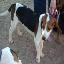

In [ ]:
imagem_teste

In [ ]:
type(imagem_teste)

PIL.Image.Image

In [ ]:
#transformando a imagem em array, pixel de 0 -255, como é colorida tera 3 dimensoes
imagem_teste = image.img_to_array(imagem_teste)

In [ ]:
imagem_teste

array([[[120., 125., 119.],
        [106., 111., 105.],
        [114., 119., 113.],
        ...,
        [ 58.,  42.,  29.],
        [ 65.,  38.,  29.],
        [ 70.,  35.,  29.]],

       [[105., 110., 104.],
        [129., 134., 128.],
        [134., 139., 133.],
        ...,
        [ 59.,  41.,  29.],
        [ 66.,  42.,  32.],
        [ 69.,  40.,  32.]],

       [[126., 131., 125.],
        [131., 136., 130.],
        [118., 123., 117.],
        ...,
        [ 64.,  40.,  30.],
        [ 64.,  42.,  31.],
        [ 63.,  41.,  30.]],

       ...,

       [[158., 165., 183.],
        [188., 198., 208.],
        [184., 196., 208.],
        ...,
        [ 96.,  90.,  92.],
        [ 90.,  84.,  86.],
        [ 76.,  70.,  72.]],

       [[170., 172., 185.],
        [196., 198., 211.],
        [189., 191., 203.],
        ...,
        [ 96.,  87.,  90.],
        [ 85.,  76.,  79.],
        [ 83.,  74.,  77.]],

       [[176., 179., 184.],
        [185., 188., 193.],
        [184., 1

In [ ]:
#padronizando, deixando a imagem com valores entre 0 e 1
imagem_teste /= 255

In [ ]:
imagem_teste

In [ ]:
imagem_teste.shape

(64, 64, 3)

In [ ]:
imagem_teste = np.expand_dims(imagem_teste, axis = 0)

In [ ]:
imagem_teste.shape

(1, 64, 64, 3)

In [ ]:
previsao = classificador.predict(imagem_teste)

In [43]:
previsao

array([[0.26454556]], dtype=float32)

In [48]:
previsao = previsao < 0.5

In [49]:
previsao

array([[ True]])

In [ ]:
base_treinamento.class_indices

In [ ]:
#carregando uma nova imagem

In [52]:
imagem_teste = image.load_img("dog1.jpg", target_size=(64,64))

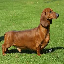

In [53]:
imagem_teste

In [54]:
imagem_teste = image.img_to_array(imagem_teste)

In [55]:
imagem_teste /= 255

In [56]:
imagem_teste.shape

(64, 64, 3)

In [57]:
imagem_teste = np.expand_dims(imagem_teste, axis = 0)

In [58]:
imagem_teste.shape

(1, 64, 64, 3)

In [59]:
prediction=classificador.predict(imagem_teste)[0]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


In [60]:
prediction

array([0.18009837], dtype=float32)

In [61]:
##Criando uma funcao para classificar uma nova imagem
def predict_image(caminho):
  imagem_teste = image.load_img(caminho, target_size=(64,64))
  imagem_teste = image.img_to_array(imagem_teste)
  imagem_teste /= 255
  imagem_teste = np.expand_dims(imagem_teste, axis = 0)

  prediction=classificador.predict(imagem_teste)[0]
  return "Cachorro" if prediction <0.5 else "Gato"


In [63]:
predict_image("dog1.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step


'Cachorro'